<a href="https://github.com/maticvl/dataHacker/tree/master/pyTorch" target="_parent">This example extends the examples at this link</a>


# Logistic Regression as a Neural Network — Pass / Fail Example

We will train a tiny neural network to predict whether a student **passes** or **fails** based on two features: the number of lectures they attended and the hours they spent on the final project.

### What is the main goal of this model?
The main goal is to separate a set of points into two classes. How can we achieve this?\
We will use a linear model and plug its output into a `sigmoid` function. The sigmoid produces a value between 0 and 1 instead of an unbounded real number — this is exactly what we need to interpret the output as the probability of class 1 ("pass").

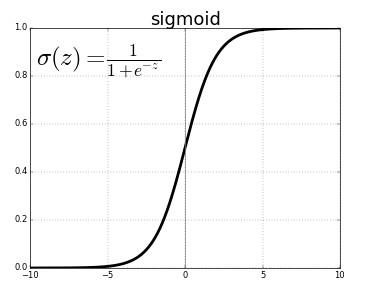

### What loss function are we going to use for this problem?
We will be using the `cross-entropy loss function`. It measures the performance of a classification model whose output is a probability value between 0 and 1.

$$ J = -\frac{1}{m} \sum_{i=1}^m y^{(i)}  [\log(\hat{y}^{(i)}) + (1-y^{(i)} )  \log(1-\hat{y}^{(i)})]$$

### Logistic Regression in Neural Network format:
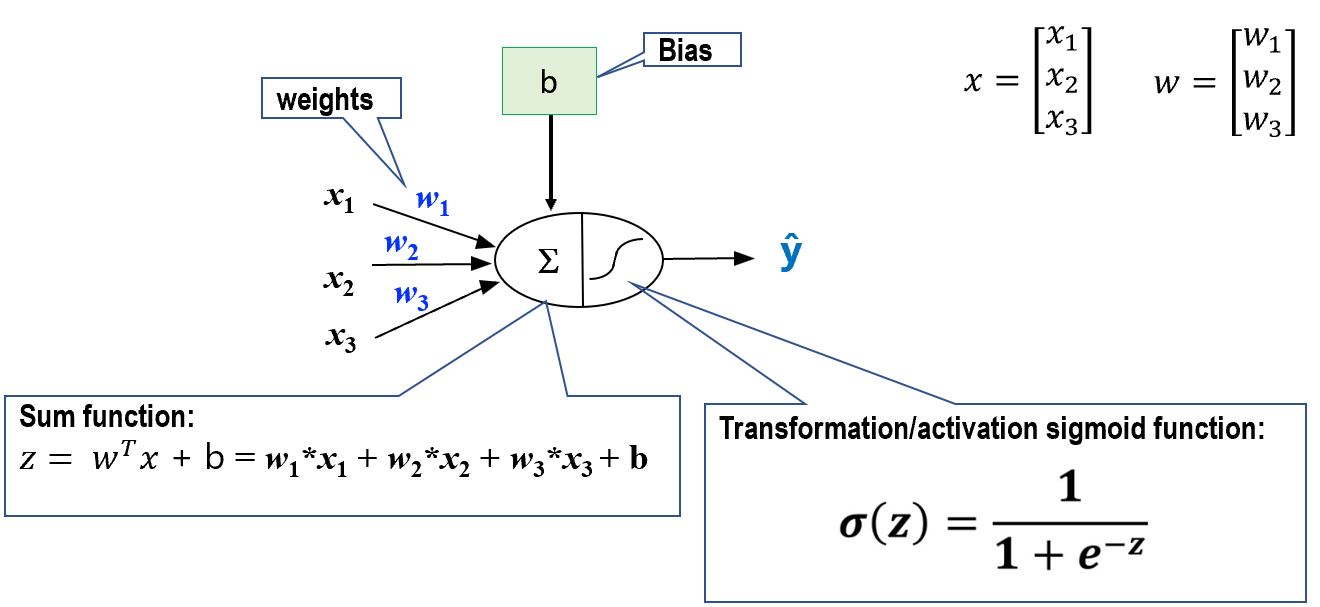

## Logistic Regression in PyTorch

We will:
1. Build a small dataset of 20 students with their lectures-attended and project-hours, labelled as pass (1) or fail (0).
2. Split it into training and test sets and convert it to PyTorch tensors.
3. Visualize the two classes to confirm they are roughly separable.


X_train shape: 16
y_train shape: 16
X_test shape: 4
y_test shape: 4


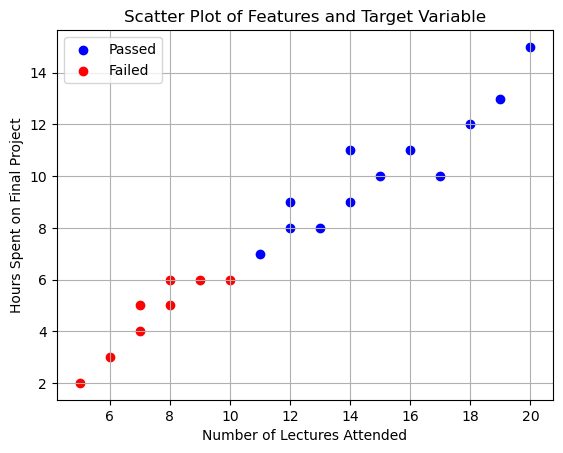

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

np.set_printoptions(suppress = True,
   formatter = {'float_kind':'{:f}'.format})

# Toy "pass / fail" dataset.
# Each row is one student described by 2 features:
#   [number of lectures attended, hours spent on the final project]
X = [
    [15, 10],
    [12, 8],
    [10, 6],
    [18, 12],
    [5, 2],
    [20, 15],
    [8, 5],
    [16, 11],
    [14, 9],
    [7, 4],
    [9, 6],
    [11, 7],
    [17, 10],
    [6, 3],
    [13, 8],
    [19, 13],
    [12, 9],
    [8, 6],
    [14, 11],
    [7, 5]
]

# Target / label: 1 = passed, 0 = failed. This is a binary classification task.
y = [1, 1, 0, 1, 0, 1, 0, 1, 1, 0,
     0, 1, 1, 0, 1, 1, 1, 0, 1, 0]

# Hold out 20% of the data for testing so we can measure generalization.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# PyTorch works with tensors, not Python lists. float32 matches the model weights.
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
# Labels need shape (N, 1) to match the single-output model and BCELoss.
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print("X_train shape:", len(X_train))
print("y_train shape:", len(y_train))
print("X_test shape:", len(X_test))
print("y_test shape:", len(y_test))

# Quick visual sanity-check: are the two classes roughly separable?
passed = [X[i] for i in range(len(X)) if y[i] == 1]
failed = [X[i] for i in range(len(X)) if y[i] == 0]

passed = plt.scatter([x[0] for x in passed], [x[1] for x in passed], color='blue', label='Passed')
failed = plt.scatter([x[0] for x in failed], [x[1] for x in failed], color='red', label='Failed')

plt.xlabel('Number of Lectures Attended')
plt.ylabel('Hours Spent on Final Project')
plt.title('Scatter Plot of Features and Target Variable')
plt.legend(handles=[passed, failed])
plt.grid(True)
plt.show()

## Defining the model

Our model is a single linear layer followed by a sigmoid:
- `nn.Linear(2, 1)` learns 2 weights and 1 bias, producing a single score `z = w·x + b`.
- `torch.sigmoid(z)` squashes `z` to a probability in (0, 1).

Before any training, the weights are random, so the prediction is essentially meaningless.

In [ ]:
# Logistic regression = a single linear layer followed by a sigmoid activation.
# The linear layer learns weights w and bias b such that  z = w . x + b,
# and the sigmoid squashes z into a probability in (0, 1).
class LogisticRegressionNN(nn.Module):
    def __init__(self, input_size):
        super(LogisticRegressionNN, self).__init__()
        # input_size features -> 1 output (probability of "pass")
        self.linear1 = nn.Linear(input_size, 1)

    def forward(self, x):
        # sigmoid turns the linear score into P(y = 1 | x)
        out = torch.sigmoid(self.linear1(x))
        return out

# Build the model: 2 inputs (lectures, hours) -> 1 probability.
input_size = X_train.shape[1]
model = LogisticRegressionNN(input_size)

# Weights and bias are randomly initialized, so predictions are meaningless at this point.
print("initial random w :", model.linear1.weight)
print("initial random b :", model.linear1.bias)

# Try the untrained model on a new student: 5 lectures, 5 hours of project work.
sample_X = torch.tensor([5, 5]).type(torch.FloatTensor)
y_pred = model(sample_X)
print(f'y_pred before training: {y_pred.item():.4f}')

initial random w : Parameter containing:
tensor([[0.2126, 0.0716]], requires_grad=True)
initial random b : Parameter containing:
tensor([-0.6848], requires_grad=True)
y_pred before training: 0.6762


## Loss function, optimizer, and training loop

We use `nn.BCELoss` (binary cross-entropy) because our output is a probability in (0, 1) and our labels are 0/1. We use the `Adam` optimizer — a gradient-descent variant with adaptive per-parameter step sizes — and train for 2000 epochs. Each epoch repeats:
1. **Forward pass** — predict probabilities for the whole training set.
2. **Loss** — compare predictions with the true labels.
3. **Backward pass** — `loss.backward()` computes the gradients.
4. **Step** — `optimizer.step()` updates the weights; `zero_grad()` clears old gradients.

In [ ]:
# Binary Cross-Entropy: the standard loss for a 0/1 label with a sigmoid output.
lossfun = nn.BCELoss()
# Use stochastic gradient descent (SGD) with a learning rate of 0.01.
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Training loop: repeat forward pass -> loss -> backward pass -> parameter update.
num_epochs = 2000
for epoch in range(num_epochs):
    # Forward pass: compute predicted probabilities for every training example.
    outputs = model(X_train)
    # Compare predictions to true labels.
    loss = lossfun(outputs, y_train)

    # Reset gradients from the previous step (PyTorch accumulates them by default).
    optimizer.zero_grad()
    # Backward pass: autograd computes d(loss)/d(parameter) for w and b.
    loss.backward()
    # Take one gradient-descent step to reduce the loss.
    optimizer.step()

    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [100/2000], Loss: 0.4148
Epoch [200/2000], Loss: 0.3357
Epoch [300/2000], Loss: 0.2835
Epoch [400/2000], Loss: 0.2471
Epoch [500/2000], Loss: 0.2201
Epoch [600/2000], Loss: 0.1991
Epoch [700/2000], Loss: 0.1821
Epoch [800/2000], Loss: 0.1680
Epoch [900/2000], Loss: 0.1561
Epoch [1000/2000], Loss: 0.1459
Epoch [1100/2000], Loss: 0.1370
Epoch [1200/2000], Loss: 0.1292
Epoch [1300/2000], Loss: 0.1223
Epoch [1400/2000], Loss: 0.1162
Epoch [1500/2000], Loss: 0.1106
Epoch [1600/2000], Loss: 0.1056
Epoch [1700/2000], Loss: 0.1010
Epoch [1800/2000], Loss: 0.0968
Epoch [1900/2000], Loss: 0.0929
Epoch [2000/2000], Loss: 0.0893


## Evaluating the trained model

After training we:
- Re-run the same `[5, 5]` sample. The probability should now be close to 0 — a student with very few lectures and project hours is predicted to **fail**.
- Evaluate on the held-out test set, rounding probabilities at 0.5 to obtain class labels.
- We wrap inference in `torch.no_grad()` to skip gradient bookkeeping (faster, less memory).

In [ ]:
# torch.no_grad() disables gradient tracking -> faster, less memory at inference time.
with torch.no_grad():
    # Same student as before, now evaluated by the trained model.
    sample_X = torch.tensor([5, 5]).type(torch.FloatTensor)
    print("w after training:", model.linear1.weight)
    print("b after training:", model.linear1.bias)
    y_pred = model(sample_X)
    print(f'y_pred after training: {y_pred.item():.4f}')

    # Predict on the held-out test set.
    y_pred = model(X_test)
    # Threshold the probabilities at 0.5 to get hard 0/1 class predictions.
    y_class = y_pred.round()
    accuracy = y_class.eq(y_test).sum() / float(y_test.shape[0])
    print(f'Accuracy on test set: {accuracy.item()*100:.2f}%')

w after training: Parameter containing:
tensor([[0.0337, 1.4953]], requires_grad=True)
b after training: Parameter containing:
tensor([-10.3002], requires_grad=True)
y_pred after training: 0.0657
Accuracy on test set: 100.00%
